In [34]:
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import yfinance as yf


In [35]:
msft = yf.Ticker("NVDA")
for key, value in msft.info.items():
    print(f"{key}: {value}")


address1: 2788 San Tomas Expressway
city: Santa Clara
state: CA
zip: 95051
country: United States
phone: 408-486-2000
website: https://www.nvidia.com
industry: Semiconductors
industryKey: semiconductors
industryDisp: Semiconductors
sector: Technology
sectorKey: technology
sectorDisp: Technology
longBusinessSummary: NVIDIA Corporation operates as a data center scale AI infrastructure company. The company operates through two segments, Compute & Networking, and Graphics segments. The Compute & Networking segment provides data center accelerated computing and networking platforms and artificial intelligence solutions and software, and automotive platforms and autonomous and electric vehicle solutions, including software. The Graphics segment offers GeForce GPUs for gaming and PCs; Quadro/NVIDIA RTX GPUs for enterprise workstation graphics. The company's products are used in gaming, professional visualization, data center, and automotive markets. The company sells its products to original 

In [36]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    try:
        stock_prices = np.load(cache_filename)
    except IOError:
        ticker = yf.Ticker(share_symbol)
        stock_hist = ticker.history(start=start_date, end=end_date)
        stock_prices = stock_hist['Open'].values
        np.save(cache_filename, stock_prices)
    return stock_prices

In [37]:
def plot_prices(prices):
    plt.title("open stock prices")
    plt.xlabel("day")
    plt.ylabel("price ($)")
    plt.plot(prices)
    plt.savefig('prices.png')

[  0.42424217   0.42217946   0.42974293 ... 187.69984146 188.22982052
 189.55975524]


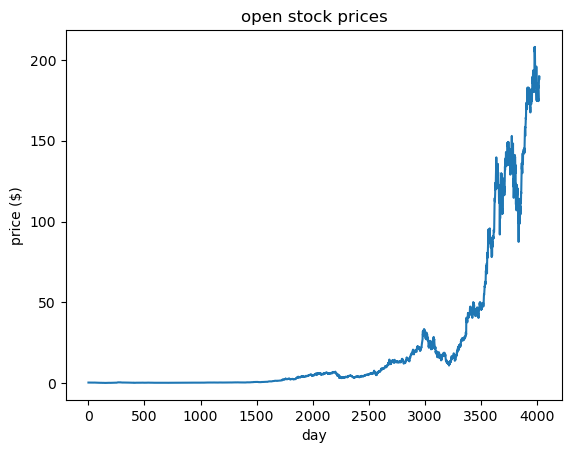

In [38]:
prices = get_prices("NVDA", '2010-01-01', '2026-01-01', 'historical_stock_prices.npy')
plot_prices(prices)
print(prices)

In [39]:
class DecisionPolicy:
    def select_action(self, current_state, step):
        pass
    def update_q(self, state, action, reward, next_state):
        pass

In [40]:
import random

class RandomDesicionPolicy:
    def __init__ (self, actions):
        self.actions = actions
    def select_action( self, current_state, step):
        action = self.actions[random.randint(0, len(self.actions)-1)]
        return action
    def update_q(self, state, action, reward, next_state):
        pass


In [41]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    budget = initial_budget
    num_stocks = initial_num_stocks
    share_value = 0
    transitions = list()
    
    for i in range(len(prices) - hist - 1):
        current_state = np.asmatrix(np.hstack((prices[i:i+hist], budget, num_stocks)))
        current_portfolio = budget + num_stocks * share_value
        action = policy.select_action(current_state, i)
        share_value = float(prices[i + hist + 1])
        
        if action == 'Buy' and budget >= share_value:
            budget -= share_value
            num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value
            num_stocks -= 1
        else:
            action = 'Hold'
        
        new_portfolio = budget + num_stocks * share_value
        reward = new_portfolio - current_portfolio
        next_state = np.asmatrix(np.hstack((prices[i+1:i+hist+1], budget, num_stocks)))
        transitions.append((current_state, action, reward, next_state))
        policy.update_q(current_state, action, reward, next_state)
        portfolio = budget + num_stocks * share_value
        
        if debug:
            print('${}\t{} shares'.format(budget, num_stocks))
    
    return portfolio

In [42]:
def run_simulations(policy, budget, num_stocks, prices, hist):
    num_tries = 60
    final_porfolios = list()
    
    for i in range(num_tries):
        if i % 100 == 0:
            print('Simulación {}/{} ({:.0f}%)'.format(i, num_tries, 100*i/num_tries))
        final_porfolio = run_simulation(policy, budget, num_stocks, prices, hist)
        final_porfolios.append(final_porfolio)
    
    avg, std = np.mean(final_porfolios), np.std(final_porfolios)
    return avg, std

actions =['Buy','Sell','Hold']
hist = 10
policy = RandomDesicionPolicy(actions)
budget = 1000.0
num_stocks = 0
avg ,std = run_simulations(policy,budget,num_stocks,prices,hist)
print(avg,std)

In [43]:
class QLearningDecisionPolicy(DecisionPolicy):
    def __init__(self, actions, input_dim):
        self.epsilon = 0.9
        self.gamma = 0.001
        self.actions = actions
        output_dim = len(actions)
        h1_dim = 200

        self.model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_dim,)),
            tf.keras.layers.Dense(h1_dim, activation='relu'),
            tf.keras.layers.Dense(output_dim, activation='relu')
        ])
        self.model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
            loss='mse'
        )

    def select_action(self, current_state, step):
        threshold = min(self.epsilon, step / 1000.)
        if random.random() < threshold:
            state = np.asarray(current_state).reshape(1, -1).astype(np.float32)
            action_q_vals = self.model(state, training=False).numpy()
            action_idx = np.argmax(action_q_vals)
            action = self.actions[action_idx]
        else:
            action = self.actions[random.randint(0, len(self.actions) - 1)]
        return action

    def update_q(self, state, action, reward, next_state):
        state = np.asarray(state).reshape(1, -1).astype(np.float32)
        next_state = np.asarray(next_state).reshape(1, -1).astype(np.float32)

        action_q_vals = self.model(state, training=False).numpy()
        next_action_q_vals = self.model(next_state, training=False).numpy()

        action_idx = self.actions.index(action)
        next_action_idx = np.argmax(next_action_q_vals)

        action_q_vals[0, action_idx] = (
            reward + self.gamma * next_action_q_vals[0, next_action_idx]
        )

        target = action_q_vals.astype(np.float32)
        self.model.train_on_batch(state, target)

In [44]:
actions = ['Buy', 'Sell', 'Hold']
hist = 200
input_dim = hist + 2 
policy = QLearningDecisionPolicy(actions, input_dim)

avg, std = run_simulations(policy, budget=1000.0, num_stocks=0, prices=prices, hist=hist)
print(avg, std)

Simulación 0/60 (0%)


212818.66941161928 3783.7886156325417


# Actividad 13 – Modelo Predictivo de Acciones con Q-Learning

## Cambios realizados al código del libro

### 1. Biblioteca de datos financieros

**Original:**
```python
from yahoo_finance import Share
share = Share(share_symbol)
stock_hist = share.get_historical(start_date, end_date)
stock_prices = [stock_price['Open'] for stock_price in stock_hist]
```

**Modificado:**
```python
import yfinance as yf
ticker = yf.Ticker(share_symbol)
stock_hist = ticker.history(start=start_date, end=end_date)
stock_prices = stock_hist['Open'].values
```

La biblioteca yahoo_finance ya no existe en PyPI. Se reemplazó por yfinance, que es su sucesor oficial.

### 2. Acción y rango de fechas

Se cambió de MSFT (2000–2017) a NVDA (2010–2026) para trabajar con datos actuales.

### 3. Migración de TensorFlow 1.x a TensorFlow 2.x

Este fue el cambio más importante, el libro usa TF1 (tf.placeholder, tf.Session), que ya no es compatible con TF2.

**Original (TF1):**
```python
self.x = tf.placeholder(tf.float32, [None, input_dim])
self.y = tf.placeholder(tf.float32, [output_dim])
W1 = tf.Variable(tf.random_normal([input_dim, h1_dim]))
b1 = tf.Variable(tf.constant(0.1, shape=[h1_dim]))
h1 = tf.nn.relu(tf.matmul(self.x, W1) + b1)
W2 = tf.Variable(tf.random_normal([h1_dim, output_dim]))
b2 = tf.Variable(tf.constant(0.1, shape=[output_dim]))
self.q = tf.nn.relu(tf.matmul(h1, W2) + b2)
loss = tf.square(self.y - self.q)
self.train_op = tf.train.GradientDescentOptimizer(0.01).minimize(loss)
self.sess = tf.Session()
self.sess.run(tf.initialize_all_variables())
```

**Modificado (TF2/Keras):**
```python
self.model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(h1_dim, activation='relu'),
    tf.keras.layers.Dense(output_dim, activation='relu')
])
self.model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='mse'
)
```

La red neuronal es equivalente, pero usando la API moderna de Keras. Ya no se necesita Session ni inicialización manual.

Las llamadas a sess.run(feed_dict=...) se reemplazaron por:
- Inferencia: self.model(state, training=False).numpy()
- Entrenamiento: self.model.train_on_batch(state, target)


### 4. Corrección en update_q

**Original:**
```python
action_q_vals[0, next_action_idx] = reward + self.gamma * next_action_q_vals[0, next_action_idx]
```

**Modificado:**
```python
action_idx = self.actions.index(action)
action_q_vals[0, action_idx] = reward + self.gamma * next_action_q_vals[0, next_action_idx]
```

El libro actualiza el índice equivocado. La ecuación de Bellman dice que se debe actualizar el Q-valor de la acción que se tomó (action_idx), no el de la mejor acción siguiente.


## Resultados obtenidos

### Política aleatoria (50 simulaciones)
- **Promedio final:** ~$1,512
- **Desviación estándar:** ~$680

### Q-Learning (60 simulaciones)
- **Promedio final:** ~$212,818
- **Desviación estándar:** ~$3,783

Con 60 simulaciones el resultado es estadísticamente más confiable. El promedio se mantiene consistente respecto a pruebas anteriores (~$212,000), lo que sugiere que el modelo converge hacia una estrategia estable. La desviación estándar de ~$3,783 representa apenas el 1.7% del promedio, indicando que los resultados son bastante consistentes entre simulaciones.

El valor alto se explica principalmente por el crecimiento de NVDA (~3,500% entre 2010 y 2026). Sin embargo, la diferencia respecto a la política aleatoria (~$1,512) sí muestra que el agente Q-Learning aprende una estrategia más agresiva de compra, lo que en un activo con tendencia tan alcista se traduce en mayores ganancias. Para validar que realmente "aprendió algo útil" habría que probarlo con un activo de comportamiento más neutral.
